In [1]:
# Install libraries
!pip install tensorflow numpy matplotlib --quiet

# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("✅ TensorFlow version:", tf.__version__)
print("✅ All libraries imported successfully!")

✅ TensorFlow version: 2.20.0
✅ All libraries imported successfully!


In [2]:
# Load MNIST dataset (built into Keras — no URL needed!)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("=== Dataset Info ===")
print(f"Training images : {X_train.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Testing images  : {X_test.shape}")
print(f"Testing labels  : {y_test.shape}")
print(f"\nPixel value range: {X_train.min()} to {X_train.max()}")
print(f"Classes (digits): {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Dataset Info ===
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)

Pixel value range: 0 to 255
Classes (digits): [0 1 2 3 4 5 6 7 8 9]


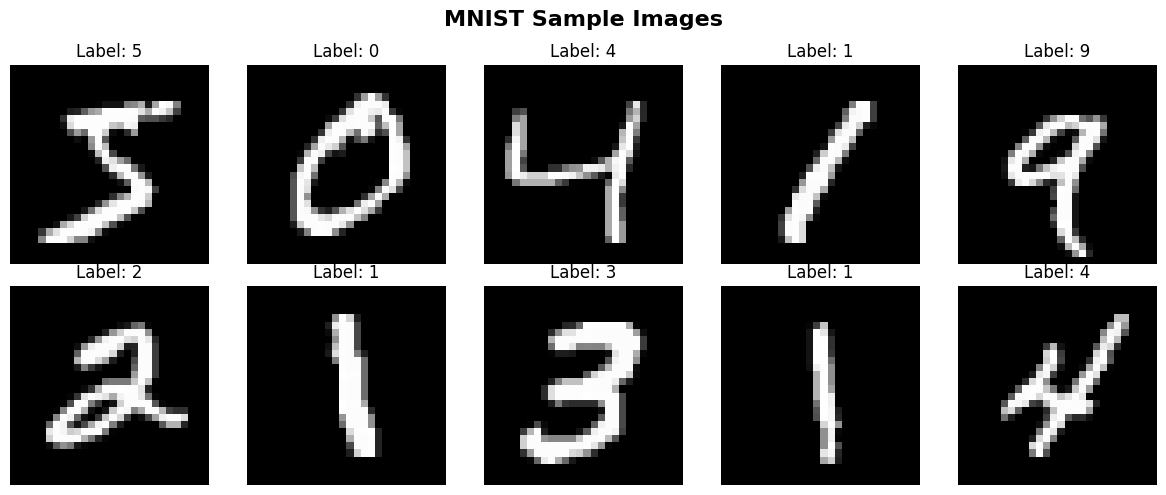

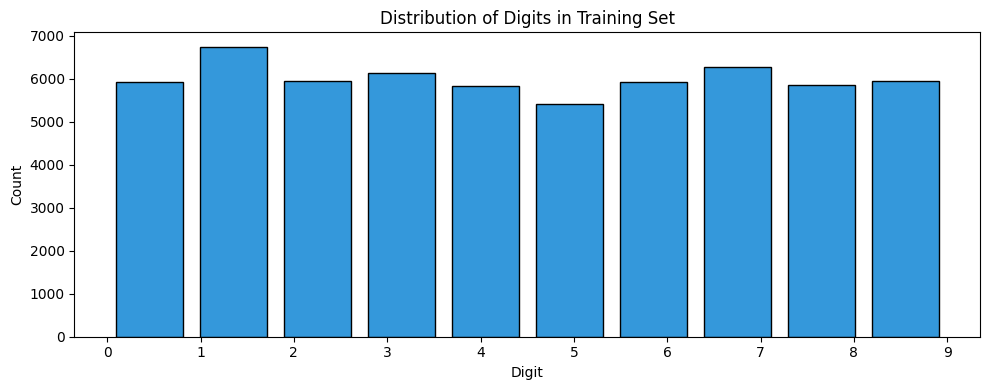

✅ Each digit appears roughly 6000 times — balanced dataset!


In [3]:
# Visualize 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MNIST Sample Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show distribution of digits
plt.figure(figsize=(10, 4))
plt.hist(y_train, bins=10, rwidth=0.8, color='#3498db', edgecolor='black')
plt.title('Distribution of Digits in Training Set')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print("✅ Each digit appears roughly 6000 times — balanced dataset!")

In [4]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape images for CNN: add channel dimension
# (60000, 28, 28) → (60000, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("=== After Preprocessing ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Pixel range   : {X_train.min()} to {X_train.max()}")
print("✅ Data preprocessed!")

=== After Preprocessing ===
X_train shape : (60000, 28, 28, 1)
X_test shape  : (10000, 28, 28, 1)
Pixel range   : 0.0 to 1.0
✅ Data preprocessed!


In [5]:
# Build CNN model
model = keras.Sequential([

    # Block 1 — First Convolution
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    # Block 2 — Second Convolution
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten & Classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.9307 - loss: 0.2252 - val_accuracy: 0.9857 - val_loss: 0.0513
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9743 - loss: 0.0875 - val_accuracy: 0.9880 - val_loss: 0.0434
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9810 - loss: 0.0627 - val_accuracy: 0.9893 - val_loss: 0.0357
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9870 - loss: 0.0447 - val_accuracy: 0.9925 - val_loss: 0.0305
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.9878 - loss: 0.0384 - val_accuracy: 0.9913 - val_loss: 0.0318
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9894 - loss: 0.0334 - val_accuracy: 0.9922 - val_loss: 0.0327
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9910 -

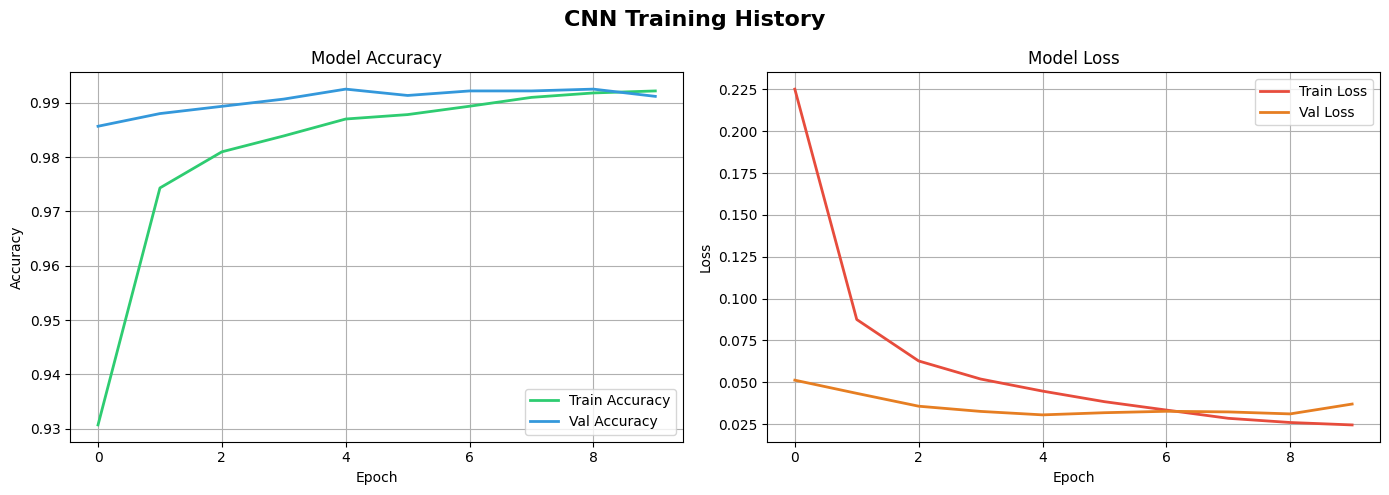


=== Final Test Results ===
Test Accuracy : 99.26%
Test Loss     : 0.0248


In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History', fontsize=16, fontweight='bold')

# Accuracy chart
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#3498db', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss chart
axes[1].plot(history.history['loss'],     label='Train Loss', color='#e74c3c', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e67e22', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== Final Test Results ===")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


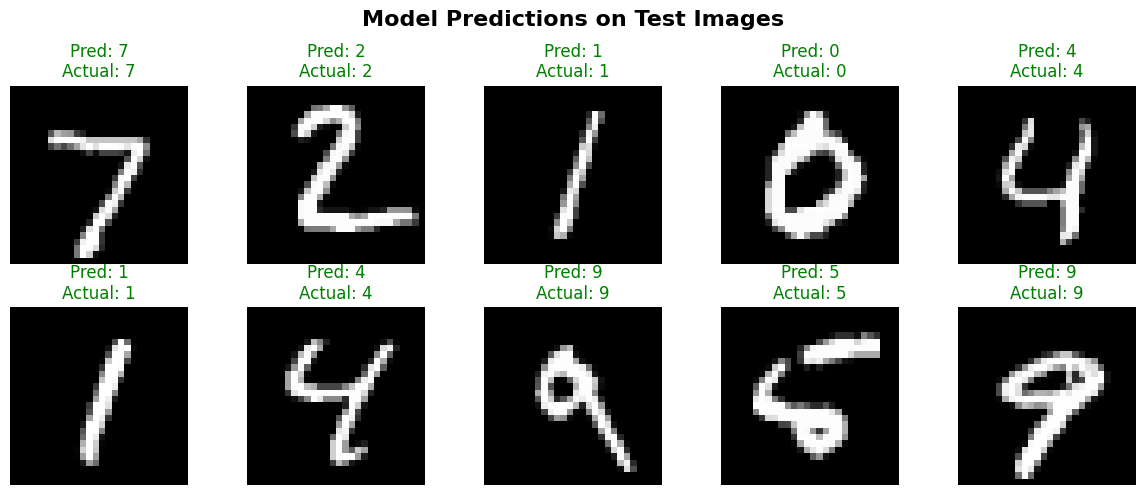

In [8]:
# Predict on 10 test images
predictions = model.predict(X_test[:10])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    predicted = np.argmax(predictions[i])
    actual    = y_test[i]
    color     = 'green' if predicted == actual else 'red'
    ax.set_title(f"Pred: {predicted}\nActual: {actual}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

✅ Dataset loaded: 60000 train, 10000 test images


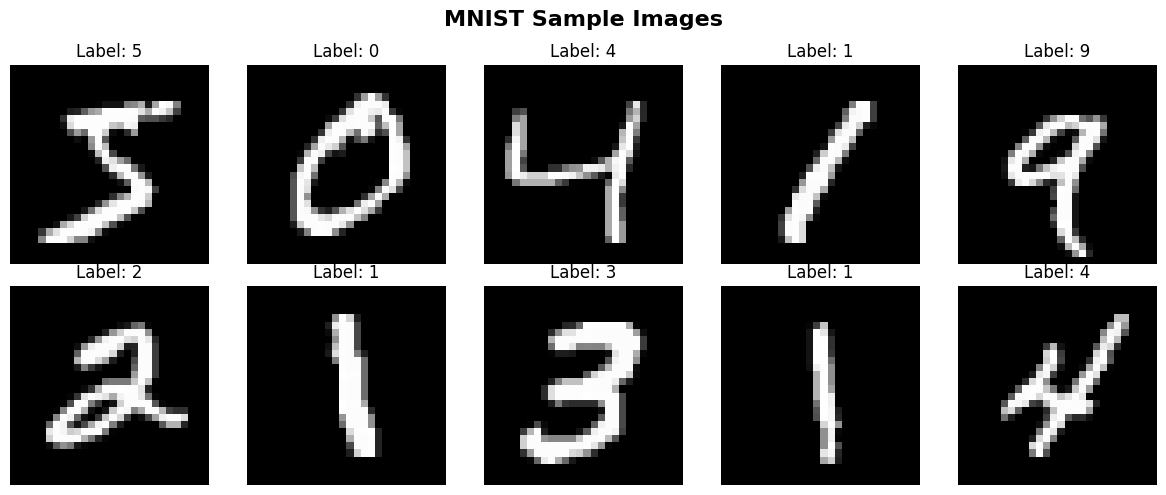

✅ Data preprocessed!
✅ Model built!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9369 - loss: 0.2063 - val_accuracy: 0.9870 - val_loss: 0.0467
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.9779 - loss: 0.0740 - val_accuracy: 0.9903 - val_loss: 0.0338
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9836 - loss: 0.0540 - val_accuracy: 0.9895 - val_loss: 0.0361
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9872 - loss: 0.0442 - val_accuracy: 0.9910 - val_loss: 0.0311
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9881 - loss: 0.0370 - val_accuracy: 0.9935 - val_loss: 0.0288
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9906 - loss: 0.0307 - val_accuracy: 0.9913 - val_loss: 0.0301
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9914 - loss: 0.0256 - val_accuracy: 0.9928 - val_loss: 0.0334
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9931 -

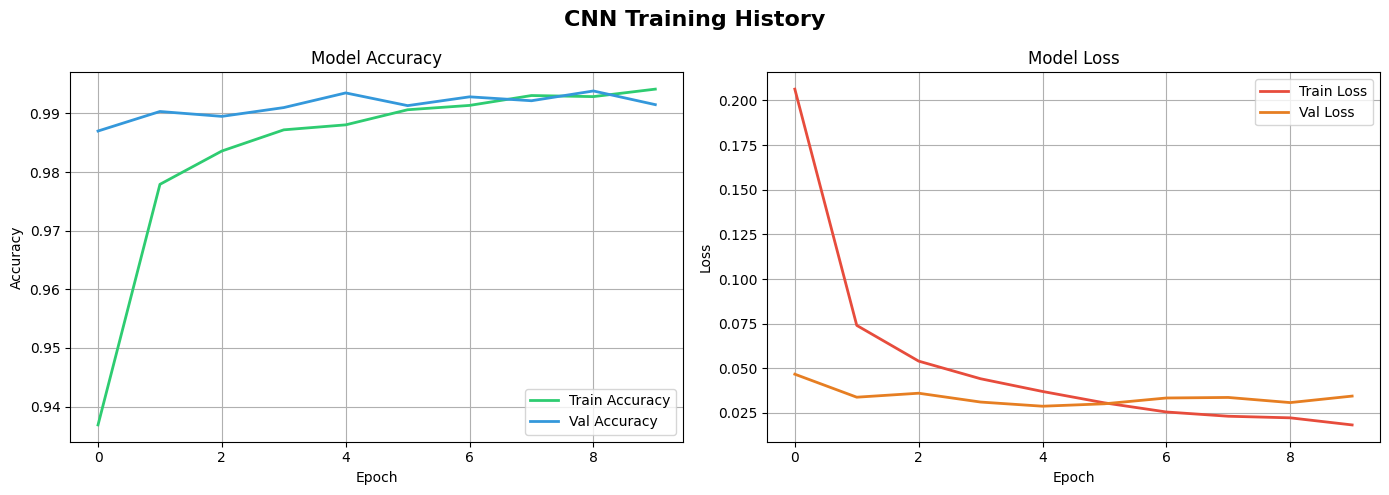

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


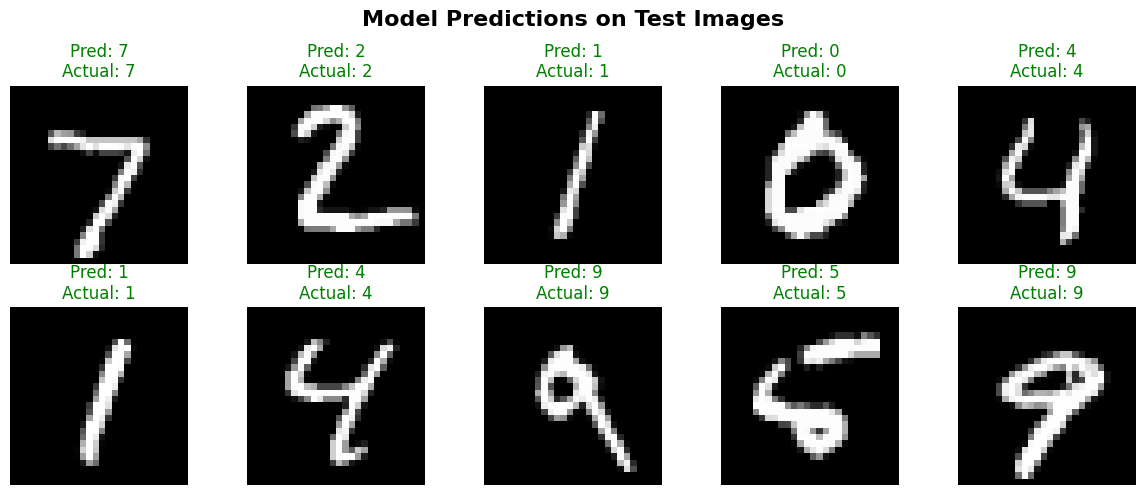


✅ Model saved as handwritten_model.h5


In [9]:
# ============================================================
#   HANDWRITTEN CHARACTER RECOGNITION
#   CodeAlpha Machine Learning Internship — Task 3
#   Author: Zeeshan Ahmad
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# ─── 1. LOAD DATA ───────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f"✅ Dataset loaded: {X_train.shape[0]} train, {X_test.shape[0]} test images")

# ─── 2. VISUALIZE SAMPLES ───────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MNIST Sample Images', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# ─── 3. PREPROCESS ──────────────────────────────────────────
X_train = X_train / 255.0
X_test  = X_test  / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)
print("✅ Data preprocessed!")

# ─── 4. BUILD CNN ───────────────────────────────────────────
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built!")
model.summary()

# ─── 5. TRAIN ───────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ─── 6. EVALUATE ────────────────────────────────────────────
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== Final Test Results ===")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# ─── 7. PLOT TRAINING HISTORY ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History', fontsize=16, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#3498db', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#e74c3c', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e67e22', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ─── 8. PREDICT ON SAMPLES ──────────────────────────────────
predictions = model.predict(X_test[:10])
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    predicted = np.argmax(predictions[i])
    actual    = y_test[i]
    color     = 'green' if predicted == actual else 'red'
    ax.set_title(f"Pred: {predicted}\nActual: {actual}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# ─── 9. SAVE MODEL ──────────────────────────────────────────
model.save('handwritten_model.h5')
print("\n✅ Model saved as handwritten_model.h5")

In [10]:
# Save in modern Keras format (recommended)
model.save('handwritten_model.keras')
print("✅ Model saved as handwritten_model.keras")

✅ Model saved as handwritten_model.keras
